# MIND Dataset — Dataset Analysis & Baseline Retrieval (A1)

**Course:** CS4.406 — Information Retrieval & Extraction (Assignment 1)  
**Dataset:** MIND — Microsoft News Dataset (Large-scale English news recommendation)  
**Competition:** [MIND Codabench](https://www.codabench.org/competitions/13967/)  
**Reference:** [MIND GitHub](https://github.com/msnews/MIND) | [Paper (ACL 2020)](https://aclanthology.org/2020.acl-main.331.pdf)

## Table of Contents
1. [Setup & Paths](#setup)
2. [Dataset Overview — File Structure](#overview)
3. [News (Articles) — Full Feature Analysis](#news)
4. [Behaviors (Train) — Click Logs & User History](#behaviors-train)
5. [Behaviors (Dev) — Validation Set](#behaviors-dev)
6. [Behaviors (Large Test) — What's Different](#behaviors-test)
7. [Entity & Relation Embeddings](#embeddings)
8. [Feature Comparison: Train vs Dev vs Test](#comparison)
9. [Generating Codabench Predictions](#predictions)
10. [Summary & Next Steps](#summary)

## 1. Setup & Paths

MIND data is in **TSV format** (not parquet like EB-NeRD). The files are much smaller and can be loaded directly with pandas/polars.

- **MINDsmall_train** — 50K sampled users, for quick experimentation
- **MINDsmall_dev** — validation set for MIND-small
- **MINDlarge_test** — full test set for Codabench submission (2.37M impressions, no labels)

In [1]:
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import json
import zipfile

# Base paths
MIND_TRAIN_DIR = Path("MINDsmall_train/MINDsmall_train")
MIND_DEV_DIR = Path("MINDsmall_dev/MINDsmall_dev")
MIND_TEST_DIR = Path("MINDlarge_test/MINDlarge_test")

# Column definitions (MIND TSVs have no headers)
BEHAVIOR_COLS = ["impression_id", "user_id", "time", "history", "impressions"]
NEWS_COLS = ["news_id", "category", "subcategory", "title", "abstract", "url", "title_entities", "abstract_entities"]

print(f"Polars: {pl.__version__}")
print(f"Train dir:  {MIND_TRAIN_DIR}  (exists: {MIND_TRAIN_DIR.exists()})")
print(f"Dev dir:    {MIND_DEV_DIR}  (exists: {MIND_DEV_DIR.exists()})")
print(f"Test dir:   {MIND_TEST_DIR}  (exists: {MIND_TEST_DIR.exists()})")

Polars: 1.43.2
Train dir:  MINDsmall_train/MINDsmall_train  (exists: True)
Dev dir:    MINDsmall_dev/MINDsmall_dev  (exists: True)
Test dir:   MINDlarge_test/MINDlarge_test  (exists: True)


## 2. Dataset Overview — File Structure

Each MIND split is a folder with 4 files:

```
MINDsmall_train/
  behaviors.tsv          — impression logs + user click history (156,965 rows)
  news.tsv               — news article metadata (51,282 articles)
  entity_embedding.vec   — 100-dim TransE entity embeddings from Wikidata
  relation_embedding.vec — 100-dim TransE relation embeddings

MINDsmall_dev/
  behaviors.tsv          — 73,152 validation impressions
  news.tsv               — 42,416 articles
  entity_embedding.vec
  relation_embedding.vec

MINDlarge_test/
  behaviors.tsv          — 2,370,727 test impressions (NO click labels!)
  news.tsv               — 120,961 articles
  entity_embedding.vec
  relation_embedding.vec
```

**Key difference from EB-NeRD:** MIND uses TSV files, has user history embedded directly in behaviors (no separate history file), and impressions are formatted as `N12345-1` (clicked) or `N12345-0` (not clicked).

In [2]:
# File sizes and row counts
for label, base in [("Train (small)", MIND_TRAIN_DIR), ("Dev (small)", MIND_DEV_DIR), ("Test (large)", MIND_TEST_DIR)]:
    print(f"=== {label} ===")
    for fname in ["behaviors.tsv", "news.tsv", "entity_embedding.vec", "relation_embedding.vec"]:
        fpath = base / fname
        if fpath.exists():
            size_mb = fpath.stat().st_size / 1e6
            with open(fpath, "r") as f:
                n_lines = sum(1 for _ in f)
            print(f"  {fname:30s}: {size_mb:>8.1f} MB  |  {n_lines:>10,} rows")
        else:
            print(f"  {fname:30s}: NOT FOUND")
    print()

=== Train (small) ===
  behaviors.tsv                 :     92.0 MB  |     156,965 rows


  news.tsv                      :     41.2 MB  |      51,282 rows
  entity_embedding.vec          :     25.8 MB  |      26,904 rows
  relation_embedding.vec        :      1.0 MB  |       1,091 rows

=== Dev (small) ===
  behaviors.tsv                 :     42.8 MB  |      73,152 rows
  news.tsv                      :     33.5 MB  |      42,416 rows


  entity_embedding.vec          :     22.0 MB  |      22,893 rows
  relation_embedding.vec        :      1.0 MB  |       1,091 rows

=== Test (large) ===


  behaviors.tsv                 :   1460.6 MB  |   2,370,727 rows
  news.tsv                      :    101.3 MB  |     120,961 rows


  entity_embedding.vec          :     44.9 MB  |      46,807 rows
  relation_embedding.vec        :      1.0 MB  |       1,091 rows



## 3. News (Articles) — Full Feature Analysis

The `news.tsv` file has 8 columns (tab-separated, no header):

| Feature | Type | Description |
|---------|------|-------------|
| `news_id` | str | Unique article ID (e.g., "N55528") |
| `category` | str | Top-level category (e.g., "lifestyle", "sports", "news") |
| `subcategory` | str | Fine-grained subcategory (e.g., "lifestyleroyals", "golf") |
| `title` | str | Article headline (English) |
| `abstract` | str | Article abstract/summary |
| `url` | str | Original MSN URL (many expired) |
| `title_entities` | str (JSON) | Named entities in title — Wikidata linked |
| `abstract_entities` | str (JSON) | Named entities in abstract — Wikidata linked |

**Note:** Full article body text is NOT provided (licensing restrictions). A crawler script is available in the [MIND repo](https://github.com/msnews/MIND/tree/master/crawler) but many URLs are expired.

**Comparison with EB-NeRD articles:** MIND lacks body text, sentiment scores, popularity stats, image IDs, and article type. But it has richer entity annotations (Wikidata IDs, confidence scores, surface forms).

In [3]:
# Load news data — small enough to read directly
news_train = pl.read_csv(
    MIND_TRAIN_DIR / "news.tsv",
    separator="\t",
    quote_char=None,
    has_header=False,
    new_columns=NEWS_COLS,
    schema_overrides={"title_entities": pl.Utf8, "abstract_entities": pl.Utf8},
)

print(f"News (train) shape: {news_train.shape}")
news_train.head(5)

News (train) shape: (51282, 8)


news_id,category,subcategory,title,abstract,url,title_entities,abstract_entities
str,str,str,str,str,str,str,str
"""N55528""","""lifestyle""","""lifestyleroyals""","""The Brands Queen Elizabeth, Pr…","""Shop the notebooks, jackets, a…","""https://assets.msn.com/labs/mi…","""[{""Label"": ""Prince Philip, Duk…","""[]"""
"""N19639""","""health""","""weightloss""","""50 Worst Habits For Belly Fat""","""These seemingly harmless habit…","""https://assets.msn.com/labs/mi…","""[{""Label"": ""Adipose tissue"", ""…","""[{""Label"": ""Adipose tissue"", ""…"
"""N61837""","""news""","""newsworld""","""The Cost of Trump's Aid Freeze…","""Lt. Ivan Molchanets peeked ove…","""https://assets.msn.com/labs/mi…","""[]""","""[{""Label"": ""Ukraine"", ""Type"": …"
"""N53526""","""health""","""voices""","""I Was An NBA Wife. Here's How …","""I felt like I was a fraud, and…","""https://assets.msn.com/labs/mi…","""[]""","""[{""Label"": ""National Basketbal…"
"""N38324""","""health""","""medical""","""How to Get Rid of Skin Tags, A…","""They seem harmless, but there'…","""https://assets.msn.com/labs/mi…","""[{""Label"": ""Skin tag"", ""Type"":…","""[{""Label"": ""Skin tag"", ""Type"":…"


In [4]:
# Null counts per column
print("=== Null Counts (News) ===")
for col in news_train.columns:
    nulls = news_train[col].null_count()
    pct = nulls / news_train.height * 100
    print(f"  {col:25s}: {nulls:>7,} nulls ({pct:5.1f}%)")

print(f"\n=== Categories ===")
print(news_train["category"].value_counts().sort("count", descending=True))

print(f"\n=== Subcategories (top 20) ===")
print(news_train["subcategory"].value_counts().sort("count", descending=True).head(20))

=== Null Counts (News) ===
  news_id                  :       0 nulls (  0.0%)
  category                 :       0 nulls (  0.0%)
  subcategory              :       0 nulls (  0.0%)
  title                    :       0 nulls (  0.0%)
  abstract                 :   2,666 nulls (  5.2%)
  url                      :       0 nulls (  0.0%)
  title_entities           :       0 nulls (  0.0%)
  abstract_entities        :       0 nulls (  0.0%)

=== Categories ===
shape: (17, 2)
┌───────────────┬───────┐
│ category      ┆ count │
│ ---           ┆ ---   │
│ str           ┆ u32   │
╞═══════════════╪═══════╡
│ news          ┆ 15774 │
│ sports        ┆ 14510 │
│ finance       ┆ 3107  │
│ foodanddrink  ┆ 2551  │
│ lifestyle     ┆ 2479  │
│ …             ┆ …     │
│ movies        ┆ 606   │
│ entertainment ┆ 587   │
│ kids          ┆ 17    │
│ middleeast    ┆ 2     │
│ northamerica  ┆ 1     │
└───────────────┴───────┘

=== Subcategories (top 20) ===
shape: (20, 2)
┌─────────────────────┬───────┐
│

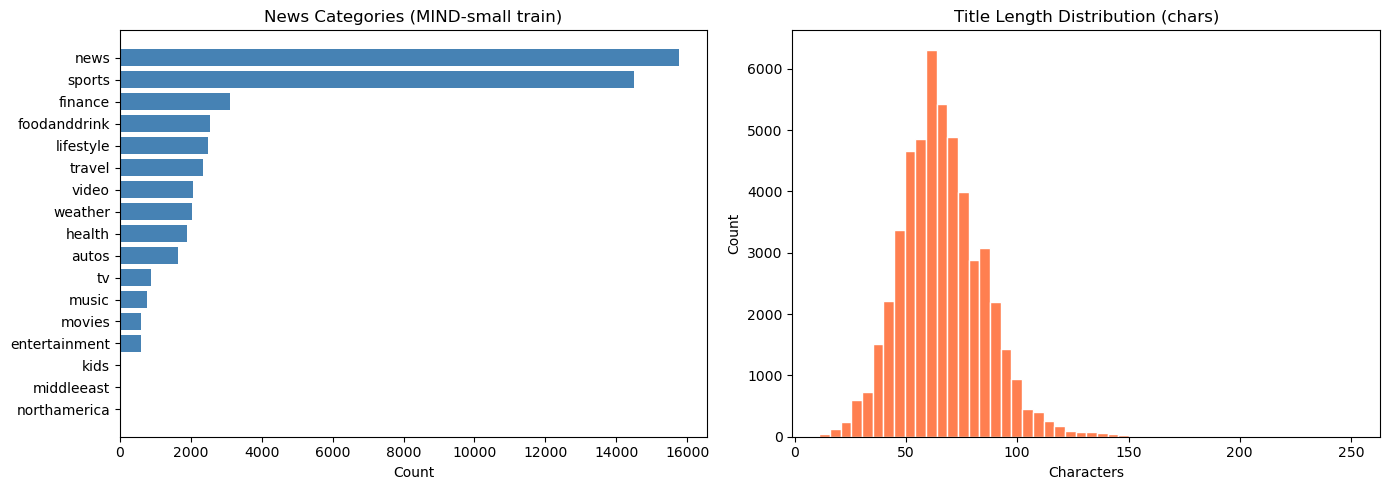

In [5]:
# Visualize category distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cat_counts = news_train["category"].value_counts().sort("count", descending=True)
axes[0].barh(cat_counts["category"].to_list(), cat_counts["count"].to_list(), color="steelblue")
axes[0].set_title("News Categories (MIND-small train)")
axes[0].invert_yaxis()
axes[0].set_xlabel("Count")

# Title length distribution
title_lens = news_train["title"].str.len_chars().drop_nulls().to_numpy()
axes[1].hist(title_lens, bins=50, color="coral", edgecolor="white")
axes[1].set_title("Title Length Distribution (chars)")
axes[1].set_xlabel("Characters")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

In [6]:
# Parse entity JSON to show structure
sample_entities = news_train.filter(pl.col("title_entities").is_not_null()).head(1)["title_entities"][0]
parsed = json.loads(sample_entities)
print("=== Sample Title Entities (first article) ===")
print(json.dumps(parsed[:3], indent=2))
print(f"\nTotal entities in this article's title: {len(parsed)}")

=== Sample Title Entities (first article) ===
[
  {
    "Label": "Prince Philip, Duke of Edinburgh",
    "Type": "P",
    "WikidataId": "Q80976",
    "Confidence": 1.0,
    "OccurrenceOffsets": [
      48
    ],
    "SurfaceForms": [
      "Prince Philip"
    ]
  },
  {
    "Label": "Charles, Prince of Wales",
    "Type": "P",
    "WikidataId": "Q43274",
    "Confidence": 1.0,
    "OccurrenceOffsets": [
      28
    ],
    "SurfaceForms": [
      "Prince Charles"
    ]
  },
  {
    "Label": "Elizabeth II",
    "Type": "P",
    "WikidataId": "Q9682",
    "Confidence": 0.97,
    "OccurrenceOffsets": [
      11
    ],
    "SurfaceForms": [
      "Queen Elizabeth"
    ]
  }
]

Total entities in this article's title: 3


## 4. Behaviors (Train) — Click Logs & User History

The `behaviors.tsv` file has 5 columns (tab-separated, no header):

| Feature | Type | Description |
|---------|------|-------------|
| `impression_id` | int | Unique impression ID |
| `user_id` | str | Anonymous user ID (e.g., "U13740") |
| `time` | str | Impression time (e.g., "11/11/2019 9:05:58 AM") |
| `history` | str | Space-separated list of clicked news IDs (user's reading history) |
| `impressions` | str | Space-separated list of `news_id-label` pairs (1=click, 0=no-click) |

**Key differences from EB-NeRD:**
- User history is **embedded in each behavior row** (not a separate file)
- Impressions format: `N55689-1 N35729-0` (news_id-clicked)
- No demographic features (gender, age, device type, etc.)
- No read time or scroll percentage
- Time period: Oct–Nov 2019 (vs EB-NeRD May 2023)

In [7]:
# Load behaviors (train) — 157K rows, small enough to load directly
behaviors_train = pl.read_csv(
    MIND_TRAIN_DIR / "behaviors.tsv",
    separator="\t",
    quote_char=None,
    has_header=False,
    new_columns=BEHAVIOR_COLS,
    schema_overrides={
        "impression_id": pl.Int64,
        "history": pl.Utf8,
        "impressions": pl.Utf8,
    },
)

print(f"Behaviors (train) shape: {behaviors_train.shape}")
behaviors_train.head(5)

Behaviors (train) shape: (156965, 5)


impression_id,user_id,time,history,impressions
i64,str,str,str,str
1,"""U13740""","""11/11/2019 9:05:58 AM""","""N55189 N42782 N34694 N45794 N1…","""N55689-1 N35729-0"""
2,"""U91836""","""11/12/2019 6:11:30 PM""","""N31739 N6072 N63045 N23979 N35…","""N20678-0 N39317-0 N58114-0 N20…"
3,"""U73700""","""11/14/2019 7:01:48 AM""","""N10732 N25792 N7563 N21087 N41…","""N50014-0 N23877-0 N35389-0 N49…"
4,"""U34670""","""11/11/2019 5:28:05 AM""","""N45729 N2203 N871 N53880 N4137…","""N35729-0 N33632-0 N49685-1 N27…"
5,"""U8125""","""11/12/2019 4:11:21 PM""","""N10078 N56514 N14904 N33740""","""N39985-0 N36050-0 N16096-0 N84…"


In [8]:
# Summary statistics
print("=== Train Behaviors Summary ===")
print(f"  Total impressions:     {behaviors_train.height:,}")
print(f"  Unique users:          {behaviors_train['user_id'].n_unique():,}")
print(f"  Impression ID range:   {behaviors_train['impression_id'].min()} - {behaviors_train['impression_id'].max()}")

# History length stats (number of articles in user's click history)
history_lens = behaviors_train["history"].fill_null("").str.split(" ").list.len()
print(f"  History length:        mean={history_lens.mean():.1f}, median={history_lens.median():.0f}, max={history_lens.max()}")

# Impressions per row (number of candidate articles shown)
impression_lens = behaviors_train["impressions"].str.split(" ").list.len()
print(f"  Impressions per row:   mean={impression_lens.mean():.1f}, median={impression_lens.median():.0f}, max={impression_lens.max()}")

# Click rate (fraction of impressions that are clicks)
def count_clicks(imp_str):
    items = imp_str.split(" ")
    return sum(1 for item in items if item.endswith("-1"))

click_counts = behaviors_train["impressions"].map_elements(count_clicks, return_dtype=pl.Int32)
total_counts = impression_lens
click_rates = click_counts / total_counts
print(f"  Click rate per impression: mean={click_rates.mean():.4f}")

# Null history (cold-start users)
null_history = behaviors_train["history"].null_count()
print(f"  Null history (cold-start): {null_history:,} ({null_history/behaviors_train.height*100:.1f}%)")

=== Train Behaviors Summary ===
  Total impressions:     156,965
  Unique users:          50,000
  Impression ID range:   1 - 156965
  History length:        mean=32.6, median=19, max=558


  Impressions per row:   mean=37.2, median=24, max=299


  Click rate per impression: mean=0.1085
  Null history (cold-start): 3,238 (2.1%)


In [9]:
# Time range
times = behaviors_train["time"].to_list()
print(f"Time range: {min(times)} to {max(times)}")

# Distribution of impressions per user
user_imp_counts = behaviors_train.group_by("user_id").agg(pl.len().alias("n_impressions")).sort("n_impressions", descending=True)
print(f"\n=== Impressions per User ===")
print(f"  Mean: {user_imp_counts['n_impressions'].mean():.2f}")
print(f"  Median: {user_imp_counts['n_impressions'].median():.0f}")
print(f"  Max: {user_imp_counts['n_impressions'].max()}")
print(f"  Top 5 most active users:")
print(user_imp_counts.head(5))

Time range: 11/10/2019 10:00:00 AM to 11/9/2019 9:59:58 AM

=== Impressions per User ===
  Mean: 3.14
  Median: 2
  Max: 62
  Top 5 most active users:
shape: (5, 2)
┌─────────┬───────────────┐
│ user_id ┆ n_impressions │
│ ---     ┆ ---           │
│ str     ┆ u32           │
╞═════════╪═══════════════╡
│ U32146  ┆ 62            │
│ U15740  ┆ 44            │
│ U20833  ┆ 41            │
│ U51286  ┆ 40            │
│ U44201  ┆ 40            │
└─────────┴───────────────┘


## 5. Behaviors (Dev) — Validation Set

The dev set has the same format as train. Used for offline evaluation before submitting to Codabench.

In [10]:
behaviors_dev = pl.read_csv(
    MIND_DEV_DIR / "behaviors.tsv",
    separator="\t",
    quote_char=None,
    has_header=False,
    new_columns=BEHAVIOR_COLS,
    schema_overrides={
        "impression_id": pl.Int64,
        "history": pl.Utf8,
        "impressions": pl.Utf8,
    },
)

print(f"Behaviors (dev) shape: {behaviors_dev.shape}")
print(f"  Unique users: {behaviors_dev['user_id'].n_unique():,}")
print(f"  Unique impressions: {behaviors_dev['impression_id'].n_unique():,}")

dev_history_lens = behaviors_dev["history"].fill_null("").str.split(" ").list.len()
print(f"  History length: mean={dev_history_lens.mean():.1f}, max={dev_history_lens.max()}")

dev_imp_lens = behaviors_dev["impressions"].str.split(" ").list.len()
print(f"  Impressions per row: mean={dev_imp_lens.mean():.1f}, max={dev_imp_lens.max()}")

dev_times = behaviors_dev["time"].to_list()
print(f"  Time range: {min(dev_times)} to {max(dev_times)}")

Behaviors (dev) shape: (73152, 5)
  Unique users: 50,000
  Unique impressions: 73,152
  History length: mean=32.3, max=444
  Impressions per row: mean=37.5, max=295
  Time range: 11/15/2019 10:00:00 AM to 11/15/2019 9:59:59 AM


## 6. Behaviors (Large Test) — What's Different

The MINDlarge_test set is what we submit to **Codabench**. Key differences:

### What's the SAME:
- `impression_id`, `user_id`, `time` — identical format
- `history` — user's click history, same format
- `impressions` — list of news articles shown

### What's DIFFERENT:
- **No click labels!** Impressions are just `N101071 N15647 N83400...` (no `-0` or `-1` suffix)
- **Much larger:** 2,370,727 impressions (vs 156,965 in small train)
- **Different time period:** Nov 19–22, 2019 (test week, after train/dev weeks)
- **Different news set:** 120,961 articles (some may not appear in train)

### What we need to predict:
For each impression, rank the candidate news articles by click probability. Output format: `impression_id [rank1,rank2,...,rankN]`

In [11]:
# Load test behaviors — 2.37M rows, still manageable with polars
# For test, impressions have NO labels (just news IDs without -0/-1)
behaviors_test = pl.read_csv(
    MIND_TEST_DIR / "behaviors.tsv",
    separator="\t",
    quote_char=None,
    has_header=False,
    new_columns=BEHAVIOR_COLS,
    schema_overrides={
        "impression_id": pl.Int64,
        "history": pl.Utf8,
        "impressions": pl.Utf8,
    },
)

print(f"Behaviors (test) shape: {behaviors_test.shape}")
print(f"  Unique users: {behaviors_test['user_id'].n_unique():,}")
print(f"  Unique impressions: {behaviors_test['impression_id'].n_unique():,}")

test_history_lens = behaviors_test["history"].fill_null("").str.split(" ").list.len()
print(f"  History length: mean={test_history_lens.mean():.1f}, max={test_history_lens.max()}")

test_imp_lens = behaviors_test["impressions"].str.split(" ").list.len()
print(f"  Impressions per row: mean={test_imp_lens.mean():.1f}, max={test_imp_lens.max()}")

test_times = behaviors_test["time"].to_list()
print(f"  Time range: {min(test_times)} to {max(test_times)}")

# Show sample — note NO -0/-1 labels in impressions
print(f"\n=== Sample (first 3 rows) ===")
print(behaviors_test.head(3))

Behaviors (test) shape: (2370727, 5)
  Unique users: 702,005
  Unique impressions: 2,370,727


  History length: mean=41.6, max=1021


  Impressions per row: mean=39.3, max=300
  Time range: 11/16/2019 10:00:00 AM to 11/22/2019 9:59:59 PM

=== Sample (first 3 rows) ===
shape: (3, 5)
┌───────────────┬─────────┬────────────────────────┬───────────────────────┬───────────────────────┐
│ impression_id ┆ user_id ┆ time                   ┆ history               ┆ impressions           │
│ ---           ┆ ---     ┆ ---                    ┆ ---                   ┆ ---                   │
│ i64           ┆ str     ┆ str                    ┆ str                   ┆ str                   │
╞═══════════════╪═════════╪════════════════════════╪═══════════════════════╪═══════════════════════╡
│ 1             ┆ U64099  ┆ 11/19/2019 11:37:45 AM ┆ N121133 N104200       ┆ N101071 N15647 N83400 │
│               ┆         ┆                        ┆ N43255 N55860 …       ┆ N124838 …             │
│ 2             ┆ U231077 ┆ 11/19/2019 5:28:08 AM  ┆ N45124 N84730 N45128  ┆ N14657 N51253 N49521  │
│               ┆         ┆                

In [12]:
# Verify: test impressions have NO labels (no -0 or -1 suffix)
sample_imp = behaviors_test["impressions"][0]
print(f"Sample impressions string: {sample_imp[:200]}...")
print(f"\nContains '-0' or '-1': {'-0' in sample_imp or '-1' in sample_imp}")

# Compare with train impressions (which DO have labels)
sample_train_imp = behaviors_train["impressions"][0]
print(f"\nTrain sample impressions: {sample_train_imp[:200]}...")
print(f"Contains '-0' or '-1': {'-0' in sample_train_imp or '-1' in sample_train_imp}")

Sample impressions string: N101071 N15647 N83400 N124838 N57092 N64623 N62785 N112133 N98744 N55764 N16531 N54103 N128905 N2296 N45689 N87027...

Contains '-0' or '-1': False

Train sample impressions: N55689-1 N35729-0...
Contains '-0' or '-1': True


## 7. Entity & Relation Embeddings

MIND provides pre-computed knowledge graph embeddings:

- **`entity_embedding.vec`** — 100-dimensional TransE embeddings for Wikidata entities
- **`relation_embedding.vec`** — 100-dimensional TransE embeddings for relations between entities

Format: first column = entity/relation ID (Wikidata Q-ID), remaining 100 columns = embedding values.

These can be used for knowledge-aware news recommendation (e.g., DKN model). EB-NeRD does not provide equivalent embeddings.

In [13]:
# Load entity embeddings (small file)
entity_emb = pl.read_csv(
    MIND_TRAIN_DIR / "entity_embedding.vec",
    separator="\t",
    quote_char=None,
    has_header=False,
    new_columns=["entity_id"] + [f"dim_{i}" for i in range(100)],
)

print(f"Entity embeddings shape: {entity_emb.shape}")
print(f"Unique entities: {entity_emb['entity_id'].n_unique():,}")
print(f"Embedding dimensions: 100")
print(f"\nSample:")
print(entity_emb.head(3))

# Relation embeddings
relation_emb = pl.read_csv(
    MIND_TRAIN_DIR / "relation_embedding.vec",
    separator="\t",
    quote_char=None,
    has_header=False,
    new_columns=["relation_id"] + [f"dim_{i}" for i in range(100)],
)

print(f"\nRelation embeddings shape: {relation_emb.shape}")
print(f"Unique relations: {relation_emb['relation_id'].n_unique():,}")

Entity embeddings shape: (26904, 102)
Unique entities: 26,904
Embedding dimensions: 100

Sample:
shape: (3, 102)
┌───────────┬───────────┬───────────┬──────────┬───┬───────────┬───────────┬──────────┬────────────┐
│ entity_id ┆ dim_0     ┆ dim_1     ┆ dim_2    ┆ … ┆ dim_97    ┆ dim_98    ┆ dim_99   ┆ column_102 │
│ ---       ┆ ---       ┆ ---       ┆ ---      ┆   ┆ ---       ┆ ---       ┆ ---      ┆ ---        │
│ str       ┆ f64       ┆ f64       ┆ f64      ┆   ┆ f64       ┆ f64       ┆ f64      ┆ str        │
╞═══════════╪═══════════╪═══════════╪══════════╪═══╪═══════════╪═══════════╪══════════╪════════════╡
│ Q41       ┆ -0.063388 ┆ -0.181451 ┆ 0.057501 ┆ … ┆ -0.101157 ┆ -0.091567 ┆ 0.035234 ┆ null       │
│ Q1860     ┆ 0.060958  ┆ 0.069934  ┆ 0.015832 ┆ … ┆ -0.133727 ┆ 0.025795  ┆ 0.051448 ┆ null       │
│ Q39631    ┆ -0.093106 ┆ -0.052002 ┆ 0.020556 ┆ … ┆ -0.144866 ┆ 0.04469   ┆ 0.013498 ┆ null       │
└───────────┴───────────┴───────────┴──────────┴───┴───────────┴───────────┴───

## 8. Feature Comparison: Train vs Dev vs Test

| Feature | Train (small) | Dev (small) | Test (large) |
|---------|:---:|:---:|:---:|
| impression_id | ✅ | ✅ | ✅ |
| user_id | ✅ | ✅ | ✅ |
| time | ✅ | ✅ | ✅ |
| history | ✅ | ✅ | ✅ |
| impressions (with labels) | ✅ `-0`/`-1` | ✅ `-0`/`-1` | ❌ no labels |
| news.tsv | ✅ 51,282 articles | ✅ 42,416 articles | ✅ 120,961 articles |
| entity_embedding.vec | ✅ | ✅ | ✅ |
| relation_embedding.vec | ✅ | ✅ | ✅ |

### MIND vs EB-NeRD Feature Comparison

| Feature | MIND | EB-NeRD |
|---------|:----:|:-------:|
| Article title | ✅ | ✅ |
| Article abstract/subtitle | ✅ | ✅ |
| Article body | ❌ (URLs expired) | ✅ |
| Category | ✅ (1 level + subcategory) | ✅ (32 categories + subcategories) |
| Sentiment | ❌ | ✅ (score + label) |
| NER/Entities | ✅ (Wikidata-linked, JSON) | ✅ (ner_clusters, entity_groups) |
| Popularity stats | ❌ | ✅ (total_inviews, pageviews, read_time) |
| Image IDs | ❌ | ✅ |
| Article type | ❌ | ✅ (16 types) |
| Premium/paywall | ❌ | ✅ |
| Entity embeddings | ✅ (TransE 100-dim) | ❌ (separate download) |
| User demographics | ❌ | ✅ (97% null though) |
| Device type | ❌ | ✅ |
| Read time / scroll % | ❌ | ✅ |
| Session ID | ❌ | ✅ |
| Subscriber flag | ❌ | ✅ |
| User history | ✅ (inline in behaviors) | ✅ (separate history.parquet) |
| Beyond-accuracy flag | ❌ | ✅ |

## 9. Generating Codabench Predictions

The MIND submission format (from the [official evaluate.py](https://github.com/msnews/MIND/blob/master/evaluate.py)):

```
impression_id [rank_order]
```

Example: `1 [5,4,9,16,11,2,1,15,7,12,13,3,6,14,8,10]`

The `[rank_order]` is a JSON list of 1-indexed ranks. Rank 1 = most likely to be clicked. The score is `1/rank` — lower rank = higher score.

**Strategy:** Popularity-based baseline — count how many times each news article was clicked in the training set, then rank candidates by click count.

In [14]:
# Step 1: Compute article popularity from train behaviors (VECTORIZED)
# Parse impressions: "N55689-1 N35729-0" -> extract clicked articles (label=1)

# Vectorized: split impressions, filter for clicks, count per news_id
popularity_df = (
    behaviors_train
    .select(pl.col("impressions").str.split(" ").alias("imp_items"))
    .explode("imp_items")
    .filter(pl.col("imp_items").str.ends_with("-1"))
    .with_columns(pl.col("imp_items").str.replace("-1", "").alias("news_id"))
    .group_by("news_id")
    .agg(pl.len().alias("click_count"))
    .sort("click_count", descending=True)
)

print(f"Unique news articles clicked in train: {popularity_df.height:,}")
print(f"Top 10 most clicked articles:")
print(popularity_df.head(10))


Unique news articles clicked in train: 7,713
Top 10 most clicked articles:
shape: (10, 2)
┌─────────┬─────────────┐
│ news_id ┆ click_count │
│ ---     ┆ ---         │
│ str     ┆ u32         │
╞═════════╪═════════════╡
│ N55689  ┆ 4316        │
│ N35729  ┆ 3346        │
│ N33619  ┆ 3246        │
│ N53585  ┆ 2835        │
│ N63970  ┆ 2578        │
│ N49685  ┆ 2294        │
│ N49279  ┆ 2270        │
│ N287    ┆ 2128        │
│ N23446  ┆ 1930        │
│ N51048  ┆ 1875        │
└─────────┴─────────────┘


/tmp/ipykernel_35354/605314148.py:8: DeprecationWarning: In Polars 2.0, the default behavior for `empty_as_null` will change to `False`. To keep the current behavior, explicitly set `empty_as_null=True`.
  .explode("imp_items")


In [15]:
# Step 2: Generate predictions for MINDlarge_test (BATCHED + VECTORIZED)
# Process in batches to avoid OOM from exploding 2.37M rows × ~50 candidates = 118M rows.
# Each batch: 200K rows → ~10M exploded rows → ~400MB. Safe for 10GB RAM.

OUTPUT_FILE = "mind_prediction.txt"
BATCH_SIZE = 200_000
total_rows = behaviors_test.height

print(f"Generating predictions for {total_rows:,} impressions in batches of {BATCH_SIZE:,}...")

predictions_written = 0

with open(OUTPUT_FILE, "w") as f:
    for start in range(0, total_rows, BATCH_SIZE):
        batch = behaviors_test.slice(start, BATCH_SIZE)

        # Vectorized: split, explode, join popularity, rank, regroup
        scored = (
            batch
            .select("impression_id", "impressions")
            .with_columns(pl.col("impressions").str.split(" ").alias("candidates"))
            .with_columns(pl.int_ranges(0, pl.col("candidates").list.len()).alias("pos"))
            .explode(["candidates", "pos"])
            .rename({"candidates": "news_id"})
            .join(popularity_df, on="news_id", how="left")
            .with_columns(pl.col("click_count").fill_null(0))
            .sort(["impression_id", "pos"])
            .with_columns(
                pl.col("click_count")
                .rank(method="ordinal", descending=True)
                .over("impression_id")
                .alias("rank")
            )
            .sort(["impression_id", "pos"])
            .group_by("impression_id")
            .agg(pl.col("rank").alias("rank_order"))
            .sort("impression_id")
        )

        # Write batch results (only file I/O loop, not computation)
        for imp_id, ranks in zip(scored["impression_id"].to_list(), scored["rank_order"].to_list()):
            f.write(f"{imp_id} [{','.join(map(str, ranks))}]\n")
        predictions_written += scored.height

        print(f"  Batch {start//BATCH_SIZE + 1}/{(total_rows + BATCH_SIZE - 1)//BATCH_SIZE}: {predictions_written:,} predictions written")

print(f"\nDone! {predictions_written:,} predictions written to {OUTPUT_FILE}")

import os
fsize = os.path.getsize(OUTPUT_FILE)
print(f"File size: {fsize / 1e6:.1f} MB")


Generating predictions for 2,370,727 impressions in batches of 200,000...


/tmp/ipykernel_35354/3755250721.py:23: DeprecationWarning: In Polars 2.0, the default behavior for `empty_as_null` will change to `False`. To keep the current behavior, explicitly set `empty_as_null=True`.
  .explode(["candidates", "pos"])


  Batch 1/12: 200,000 predictions written


  Batch 2/12: 400,000 predictions written


  Batch 3/12: 600,000 predictions written


...

  Batch 8/12: 1,600,000 predictions written


  Batch 9/12: 1,800,000 predictions written


  Batch 10/12: 2,000,000 predictions written


  Batch 11/12: 2,200,000 predictions written


  Batch 12/12: 2,370,727 predictions written

Done! 2,370,727 predictions written to mind_prediction.txt
File size: 291.3 MB


In [16]:
# Verify the output format matches the expected MIND format
print("=== First 5 lines of mind_prediction.txt ===")
with open(OUTPUT_FILE, "r") as f:
    for i, line in enumerate(f):
        if i >= 5:
            break
        print(line.rstrip())

# Compare with the official sample prediction
print("\n=== Official sample prediction (from MIND repo) ===")
with open("MIND_repo/sample_pred/prediction.txt", "r") as f:
    for i, line in enumerate(f):
        if i >= 5:
            break
        print(line.rstrip())

=== First 5 lines of mind_prediction.txt ===
1 [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16]
2 [3,1,2,4,5,6,7]
3 [5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,1,25,26,27,28,29,2,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,3,75,76,4,77,78,79,80,81,82]
4 [5,6,7,8,9,10,11,12,4,13,2,14,15,16,17,18,19,20,21,22,23,3,24,25,1,26,27,28,29,30,31,32,33,34,35]
5 [2,1,4,3,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37]

=== Official sample prediction (from MIND repo) ===
1 [5,4,9,16,11,2,1,15,7,12,13,3,6,14,8,10]
2 [34,77,8,86,94,81,87,51,46,42,60,85,95,22,35,91,69,6,14,7,100,102,106,58,65,33,71,55,3,97,53,44,82,5,70,1,80,105,50,67,27,88,16,63,101,90,4,84,47,38,29,18,113,28,26,89,96,49,62,10,79,25,76,61,32,66,11,98,92,13,114,39,43,112,115,103,36,21,64,68,52,23,56,107,116,2,59,75,15,20,72,57,37,110,108,12,19,74,24,48,45,17,83,78,73,111,99,104,31,9,41,54,109,9

In [17]:
# Step 3: Zip the predictions for Codabench upload
ZIP_FILE = "mind_prediction.zip"
with zipfile.ZipFile(ZIP_FILE, "w", zipfile.ZIP_DEFLATED) as zf:
    zf.write(OUTPUT_FILE)

zip_size = Path(ZIP_FILE).stat().st_size
print(f"Created {ZIP_FILE} ({zip_size / 1e6:.1f} MB)")
print(f"\nUpload {ZIP_FILE} to: https://www.codabench.org/competitions/13967/")

Created mind_prediction.zip (28.1 MB)

Upload mind_prediction.zip to: https://www.codabench.org/competitions/13967/


## 10. Summary & Next Steps

### MIND Dataset Key Findings:

- **News articles (51K train / 121K test):** 8 columns — news_id, category, subcategory, title, abstract, url, title_entities, abstract_entities. No body text, no sentiment, no popularity stats. Rich Wikidata entity annotations with confidence scores.
- **Behaviors (157K train / 73K dev / 2.37M test):** 5 columns — impression_id, user_id, time, history, impressions. User history is inline (space-separated news IDs). Impressions are `news_id-label` pairs (train/dev) or just `news_id` (test).
- **Entity embeddings:** 100-dim TransE embeddings from Wikidata knowledge graph — unique to MIND, not in EB-NeRD.
- **Test set:** 2.37M impressions, no click labels, Nov 19–22 2019. Need to rank candidates per impression.

### MIND vs EB-NeRD:
- MIND is **English**, EB-NeRD is **Danish**
- MIND is **TSV**, EB-NeRD is **Parquet**
- MIND has **inline history**, EB-NeRD has **separate history file**
- MIND has **entity embeddings**, EB-NeRD has **sentiment + popularity + body text**
- MIND has **no demographics**, EB-NeRD has (mostly null) demographics
- Both use the **same prediction format**: `impression_id [rank_order]`

### Prediction baseline (A1):
- Popularity-based ranking (most-clicked articles first)
- Output: `mind_prediction.txt` → `mind_prediction.zip`
- Upload to [MIND Codabench](https://www.codabench.org/competitions/13967/)

### Next steps for A1:
1. **BM25 lexical retrieval:** Build inverted index over news titles/abstracts, retrieve top-K candidates using user history as query
2. **Embedding-based semantic retrieval:** Use entity embeddings or compute BERT embeddings, build ANN index, mean-pool user history
3. **Evaluation harness:** Implement AUC, MRR, nDCG@5, nDCG@10, plus diversity/novelty/coverage with bootstrap CIs
4. **Recall@K analysis:** Compare lexical vs semantic retrieval for K in {50, 100, 200}
5. **Slicing:** Cold-start vs warm users, head vs tail articles
